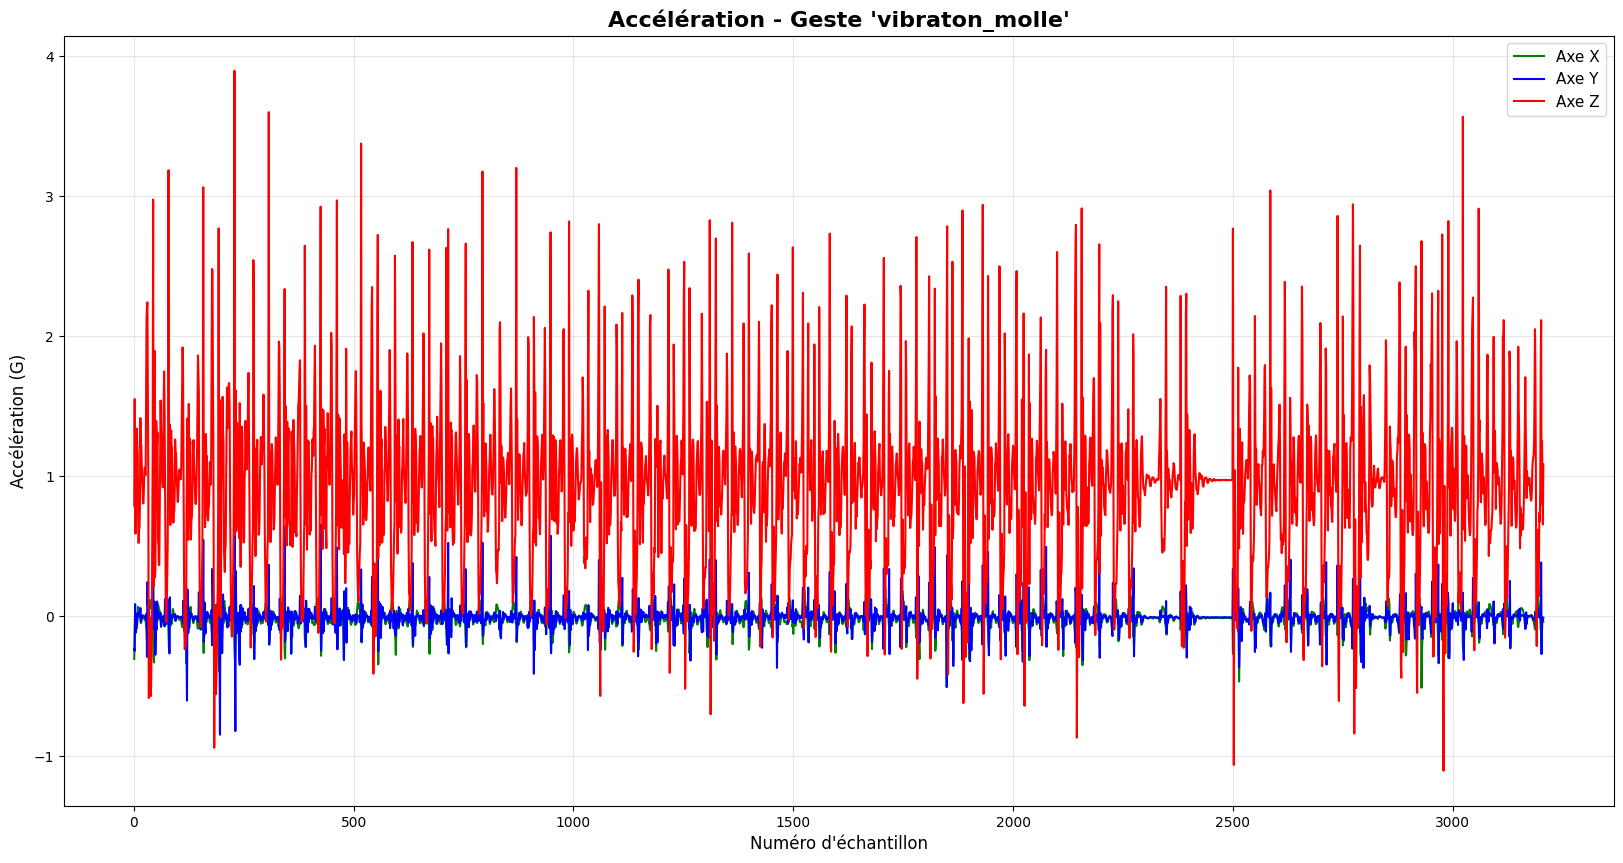

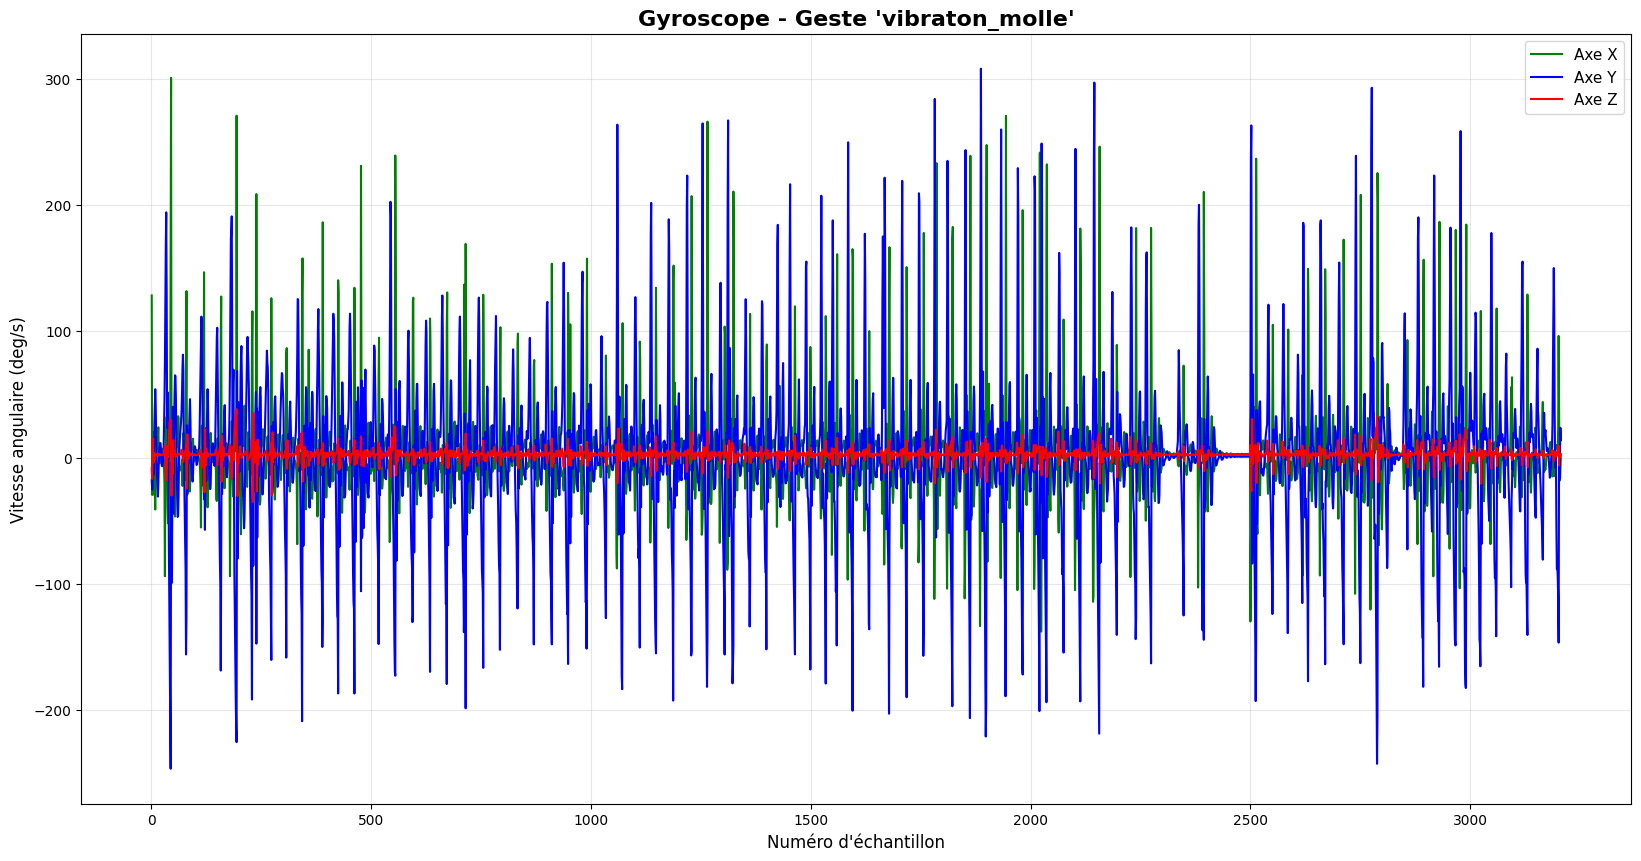

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Charger les données du geste "punch" (coup de poing)
filename = "vibraton_molle.csv"

# Utiliser le chemin relatif pour compatibilité Windows
df = pd.read_csv(filename)

# Créer un index pour l'axe X (numéro d'échantillon)
index = range(1, len(df['aX']) + 1)

# Définir la taille des graphiques (largeur, hauteur en pouces)
plt.rcParams["figure.figsize"] = (20, 10)

# Graphique 1 : Accélération
# Les couleurs : vert (g) pour X, bleu (b) pour Y, rouge (r) pour Z
plt.plot(index, df['aX'], 'g-', label='Axe X', linewidth=1.5)
plt.plot(index, df['aY'], 'b-', label='Axe Y', linewidth=1.5)
plt.plot(index, df['aZ'], 'r-', label='Axe Z', linewidth=1.5)
plt.title("Accélération - Geste 'vibraton_molle'", fontsize=16, fontweight='bold')
plt.xlabel("Numéro d'échantillon", fontsize=12)
plt.ylabel("Accélération (G)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Graphique 2 : Gyroscope
plt.plot(index, df['gX'], 'g-', label='Axe X', linewidth=1.5)
plt.plot(index, df['gY'], 'b-', label='Axe Y', linewidth=1.5)
plt.plot(index, df['gZ'], 'r-', label='Axe Z', linewidth=1.5)
plt.title("Gyroscope - Geste 'vibraton_molle'", fontsize=16, fontweight='bold')
plt.xlabel("Numéro d'échantillon", fontsize=12)
plt.ylabel("Vitesse angulaire (deg/s)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()




In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"Version TensorFlow = {tf.__version__}\n")

# ============================================
# REPRODUCTIBILITÉ
# ============================================
# Définir une graine aléatoire fixe pour obtenir les mêmes résultats
# à chaque exécution. Important pour la reproductibilité des expériences.
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================
# CONFIGURATION DES GESTES
# ============================================
# Liste des gestes à reconnaître (doit correspondre aux noms des fichiers CSV)
GESTURES = [
    "/content/vibraton_agiter",  # Corrected filename: 'vibraton' instead of 'vibration'
    "/content/vibraton_molle"    # Corrected filename: 'vibraton' instead of 'vibratiob' and 'Faible' capitalization
]

# Nombre d'échantillons par geste (119 échantillons = ~2 secondes à 50Hz)
SAMPLES_PER_GESTURE = 119

NUM_GESTURES = len(GESTURES)

# ============================================
# ONE-HOT ENCODING
# ============================================
# Créer une matrice d'encodage one-hot pour les sorties
# vibraton_agiter  → [1, 0]
# vibraton_molle     → [0, 1]
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)
print("Encodage one-hot:")
for i, gesture in enumerate(GESTURES):
    print(f"  {gesture}: {ONE_HOT_ENCODED_GESTURES[i]}")

# ============================================
# PRÉPARATION DES DONNÉES
# ============================================
inputs = []  # Liste des entrées (données normalisées)
outputs = []  # Liste des sorties (labels one-hot)

# Parcourir chaque fichier CSV de geste
for gesture_index in range(NUM_GESTURES):
    gesture = GESTURES[gesture_index]
    print(f"\n📁 Traitement de l'index {gesture_index} pour le geste '{gesture}'...")

    # Récupérer le vecteur one-hot correspondant à ce geste
    output = ONE_HOT_ENCODED_GESTURES[gesture_index]

    # Lire le fichier CSV
    df = pd.read_csv(gesture + ".csv")

    # Supprimer les lignes vides qui causeraient des erreurs (NaN)
    df = df.dropna()
    df = df.reset_index(drop=True)

    # Calculer le nombre d'enregistrements de ce geste dans le fichier
    # Chaque enregistrement = SAMPLES_PER_GESTURE échantillons
    num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)
    print(f"   ✓ {num_recordings} enregistrement(s) du geste '{gesture}' trouvé(s)")

    # Pour chaque enregistrement du geste
    for i in range(num_recordings):
        tensor = []  # Vecteur d'entrée pour cet enregistrement

        # Pour chaque échantillon dans cet enregistrement
        for j in range(SAMPLES_PER_GESTURE):
            index = i * SAMPLES_PER_GESTURE + j

            # ============================================
            # NORMALISATION DES DONNÉES
            # ============================================
            # Convertir les valeurs brutes en valeurs entre 0 et 1
            # Formule: (valeur - min) / (max - min)
            #
            # Accélération: de -4G à +4G → normalisée entre 0 et 1
            #   (valeur + 4) / 8
            #
            # Gyroscope: de -2000 à +2000 deg/s → normalisée entre 0 et 1
            #   (valeur + 2000) / 4000

            tensor += [
                (df['aX'][index] + 4) / 8,      # Accélération X normalisée
                (df['aY'][index] + 4) / 8,      # Accélération Y normalisée
                (df['aZ'][index] + 4) / 8,      # Accélération Z normalisée
                (df['gX'][index] + 2000) / 4000,  # Gyroscope X normalisé
                (df['gY'][index] + 2000) / 4000,  # Gyroscope Y normalisé
                (df['gZ'][index] + 2000) / 4000   # Gyroscope Z normalisé
            ]

        # Ajouter cet enregistrement aux listes
        inputs.append(tensor)   # 714 valeurs (119 échantillons × 6 valeurs)
        outputs.append(output)   # Vecteur one-hot [1,0] ou [0,1]

# Convertir les listes en tableaux NumPy (format requis par TensorFlow)
inputs = np.array(inputs)
outputs = np.array(outputs)

print(f"\n✅ Préparation des données terminée !")
print(f"   - Nombre total d'enregistrements: {len(inputs)}")
print(f"   - Taille de chaque entrée: {inputs.shape[1]} valeurs")
print(f"   - Nombre de gestes: {NUM_GESTURES}")

Version TensorFlow = 2.19.0

Encodage one-hot:
  /content/vibraton_agiter: [1. 0.]
  /content/vibraton_molle: [0. 1.]

📁 Traitement de l'index 0 pour le geste '/content/vibraton_agiter'...
   ✓ 28 enregistrement(s) du geste '/content/vibraton_agiter' trouvé(s)

📁 Traitement de l'index 1 pour le geste '/content/vibraton_molle'...
   ✓ 26 enregistrement(s) du geste '/content/vibraton_molle' trouvé(s)

✅ Préparation des données terminée !
   - Nombre total d'enregistrements: 54
   - Taille de chaque entrée: 714 valeurs
   - Nombre de gestes: 2


In [ ]:
# ============================================
# MÉLANGER LES DONNÉES
# ============================================
# Créer un ordre aléatoire pour mélanger les données
# Cela garantit une distribution équilibrée dans chaque ensemble
num_inputs = len(inputs)
randomize = np.arange(num_inputs)  # [0, 1, 2, ..., num_inputs-1]
np.random.shuffle(randomize)        # Mélanger: [5, 12, 3, 0, ...]

# Réorganiser les données selon l'ordre aléatoire
inputs = inputs[randomize]
outputs = outputs[randomize]

# ============================================
# DIVISER EN TROIS ENSEMBLES
# ============================================
# Calculer les indices de division
# 60% pour l'entraînement, 20% pour la validation, 20% pour le test
TRAIN_SPLIT = int(0.6 * num_inputs)      # 60% des données
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)  # 60% + 20% = 80%

# Diviser les données
inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("✅ Mélange et division des données terminés !")
print(f"\n📊 Répartition des données :")
print(f"   - Entraînement : {len(inputs_train)} échantillons ({len(inputs_train)/num_inputs*100:.1f}%)")
print(f"   - Validation   : {len(inputs_validate)} échantillons ({len(inputs_validate)/num_inputs*100:.1f}%)")
print(f"   - Test         : {len(inputs_test)} échantillons ({len(inputs_test)/num_inputs*100:.1f}%)")

✅ Mélange et division des données terminés !

📊 Répartition des données :
   - Entraînement : 32 échantillons (59.3%)
   - Validation   : 12 échantillons (22.2%)
   - Test         : 10 échantillons (18.5%)


In [ ]:
# ============================================
# CONSTRUCTION DU MODÈLE
# ============================================
# Créer un modèle séquentiel (couches empilées les unes après les autres)


# model.fit(..., callbacks=[early]) # This line caused the error, it's a placeholder

model = tf.keras.Sequential()

# Couche 1 : 50 neurones avec activation ReLU
# - ReLU est rapide et performante pour les réseaux de neurones
# - 50 neurones = capacité d'apprentissage intermédiaire
model.add(tf.keras.layers.Dense(50, activation='relu', name='couche_cachee_1'))

# Couche 2 : 15 neurones avec activation ReLU
# - Réduction progressive vers la sortie
# - Aide le modèle à apprendre des représentations plus abstraites
model.add(tf.keras.layers.Dense(15, activation='relu', name='couche_cachee_2'))

# Couche de sortie : NUM_GESTURES neurones (2 dans notre cas) avec activation softmax
# - Softmax convertit les valeurs en probabilités (somme = 1)
# - Chaque neurone représente la probabilité d'un geste
# - Exemple de sortie : [0.95, 0.05] = 95% punch, 5% flex
model.add(tf.keras.layers.Dense(NUM_GESTURES, activation='softmax', name='couche_sortie'))

# ============================================
# COMPILATION DU MODÈLE
# ============================================
# Configurer comment le modèle va apprendre

# Optimiseur : RMSprop
# - Algorithme qui ajuste les poids pendant l'apprentissage
# - RMSprop adapte le taux d'apprentissage pour chaque paramètre
# - Bon compromis vitesse/stabilité

# Fonction de perte (Loss) : MSE (Mean Squared Error)
# - Mesure l'erreur entre les prédictions et les vraies valeurs
# - Formule : moyenne((prédiction - vraie_valeur)²)
# - Plus la loss est faible, meilleur est le modèle


# Métrique : MAE (Mean Absolute Error)
# - Erreur absolue moyenne
# - Plus facile à interpréter que MSE (même unité que les données)
model.compile(
    optimizer='rmsprop',      # Algorithme d'optimisation
    loss='mse',                # Fonction de perte (Mean Squared Error)
    metrics=['mae']            # Métrique à suivre (Mean Absolute Error)
)

# Afficher un résumé de l'architecture
print("📐 Architecture du modèle :")
model.summary()

print("\n🚀 Démarrage de l'entraînement...")
print("   - Epochs : 600 (nombre de passages sur toutes les données)")
print("   - Batch size : 1 (traitement d'un échantillon à la fois)")
print("   - Cela peut prendre quelques minutes...\n")

# ============================================
# ENTRAÎNEMENT DU MODÈLE
# ============================================
# epochs : nombre de fois que le modèle voit toutes les données d'entraînement
# batch_size : nombre d'échantillons traités avant de mettre à jour les poids
# validation_data : données pour évaluer les performances pendant l'entraînement
history = model.fit(
    inputs_train,              # Données d'entraînement
    outputs_train,            # Labels d'entraînement
    epochs=400,               # Nombre d'itérations
    batch_size=1,             # Taille du lot (1 = mise à jour après chaque échantillon)
    validation_data=(inputs_validate, outputs_validate),  # Données de validation
    verbose=1                  # Afficher la progression

)

print("\n✅ Entraînement terminé !")

📐 Architecture du modèle :


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_cachee_1 (Dense)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_cachee_2 (Dense)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_sortie (Dense)           │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Démarrage de l'entraînement...
   - Epochs : 600 (nombre de passages sur toutes les données)
   - Batch size : 1 (traitement d'un échantillon à la fois)
   - Cela peut prendre quelques minutes...

Epoch 1/400
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3615 - mae: 0.5460 - val_loss: 0.3194 - val_mae: 0.5490
Epoch 2/400
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3001 - mae: 0.5285 - val_loss: 0.2826 - val_mae: 0.5265
Epoch 3/400
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2670 - mae: 0.5094 - val_loss: 0.2941 - val_mae: 0.5341
Epoch 4/400
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2693 - mae: 0.5099 - val_loss: 0.2952 - val_mae: 0.5346
Epoch 5/400
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2589 - mae: 0.5003 - val_loss: 0.2943 - val_mae: 0.5340
Epoch 6/400
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2561 - mae: 0.4912 - val_loss: 0.3786 - val_mae: 0.5769
Epoch 7/400
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2868 - mae: 0.5023 - val_loss: 0.3095

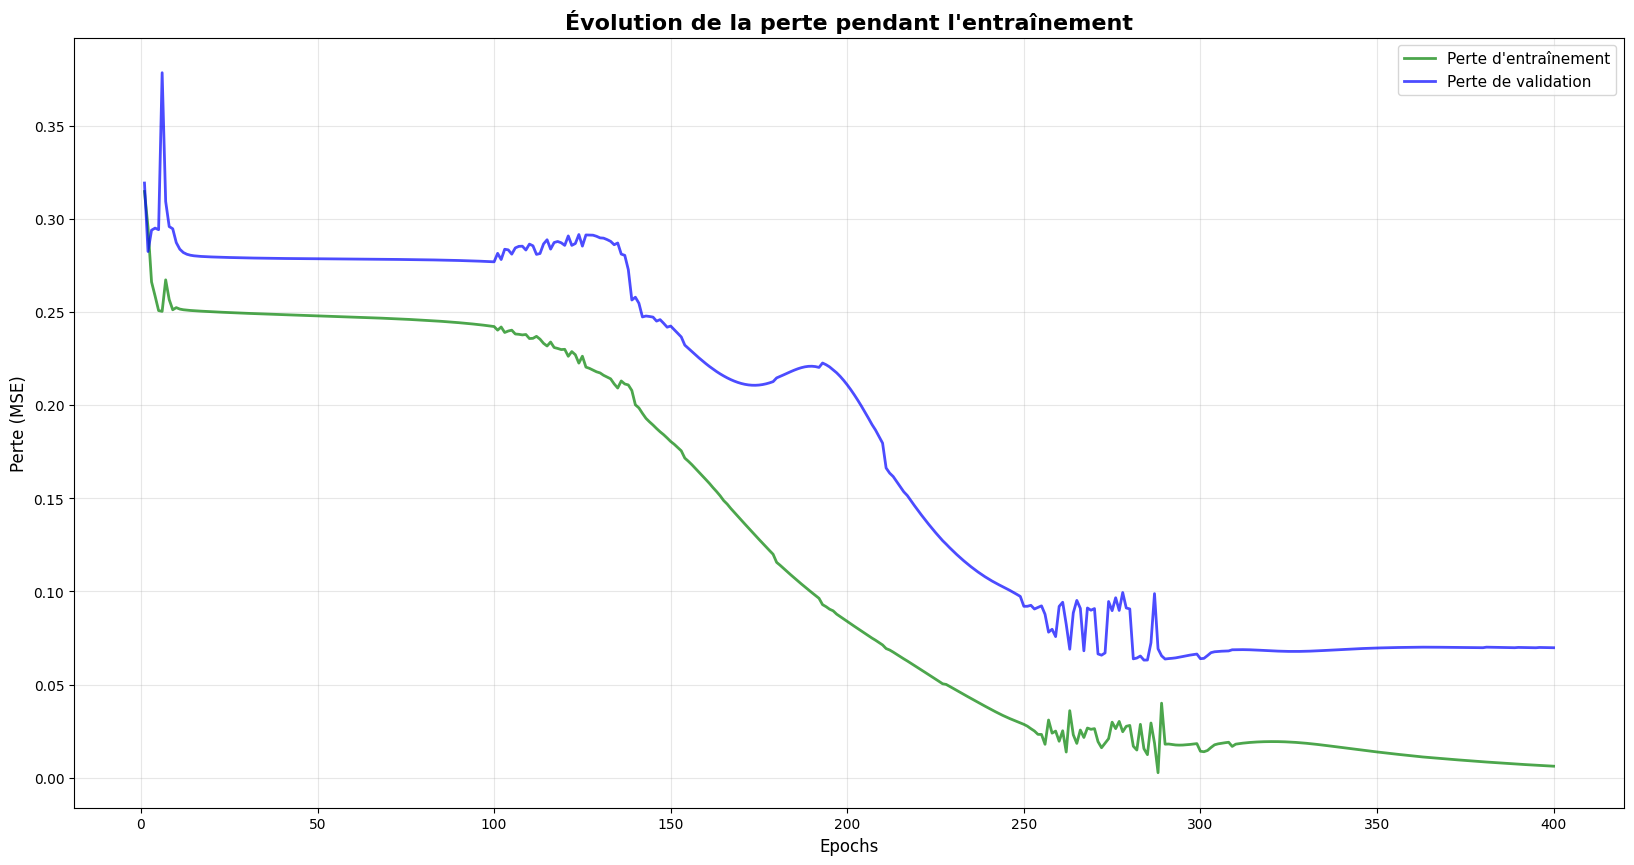

📊 Graphique généré avec 400 epochs
   - Perte finale d'entraînement : 0.0062
   - Perte finale de validation : 0.0698


In [ ]:
# Définir la taille des graphiques (largeur, hauteur en pouces)
plt.rcParams["figure.figsize"] = (20, 10)

# Extraire les valeurs de perte de l'historique d'entraînement
loss = history.history['loss']           # Perte sur les données d'entraînement
val_loss = history.history['val_loss']  # Perte sur les données de validation
epochs = range(1, len(loss) + 1)        # Numéros des epochs (1, 2, 3, ...)

# Créer le graphique
plt.plot(epochs, loss, 'g-', label='Perte d\'entraînement', linewidth=2, alpha=0.7)
plt.plot(epochs, val_loss, 'b-', label='Perte de validation', linewidth=2, alpha=0.7)
plt.title('Évolution de la perte pendant l\'entraînement', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Perte (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"📊 Graphique généré avec {len(loss)} epochs")
print(f"   - Perte finale d'entraînement : {loss[-1]:.4f}")
print(f"   - Perte finale de validation : {val_loss[-1]:.4f}")

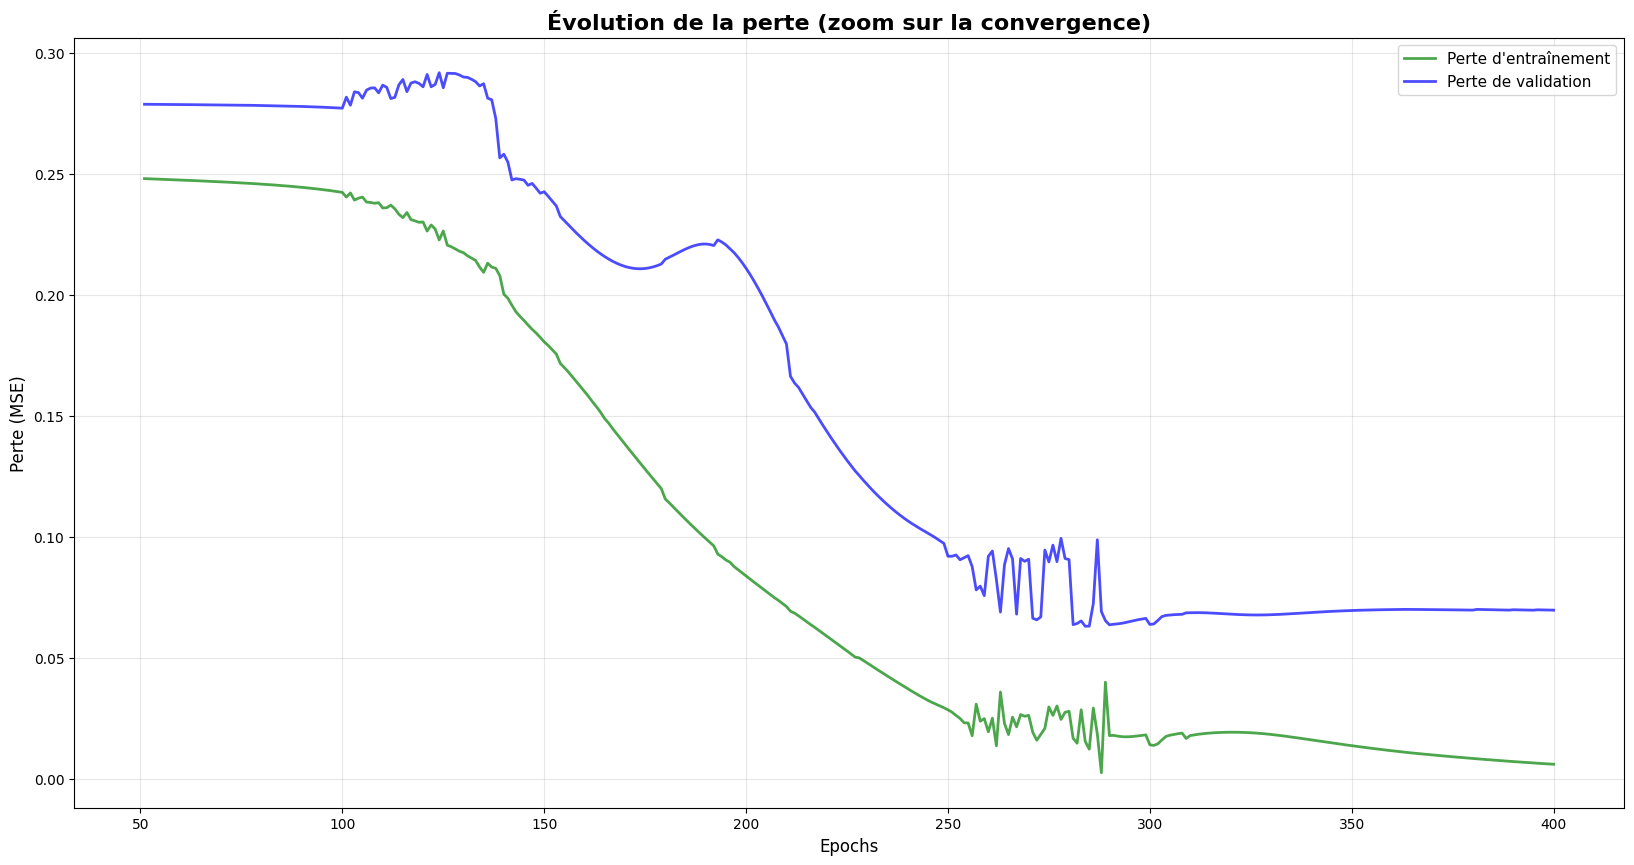

🔍 Vue zoomée à partir de l'epoch 51


In [ ]:
# Graphique de la perte en sautant les premiers epochs
# Cela permet de mieux voir la convergence (stabilisation) du modèle
SKIP = 50  # Ignorer les 100 premiers epochs

plt.plot(epochs[SKIP:], loss[SKIP:], 'g-', label='Perte d\'entraînement', linewidth=2, alpha=0.7)
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b-', label='Perte de validation', linewidth=2, alpha=0.7)
plt.title('Évolution de la perte (zoom sur la convergence)', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Perte (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"🔍 Vue zoomée à partir de l'epoch {SKIP+1}")

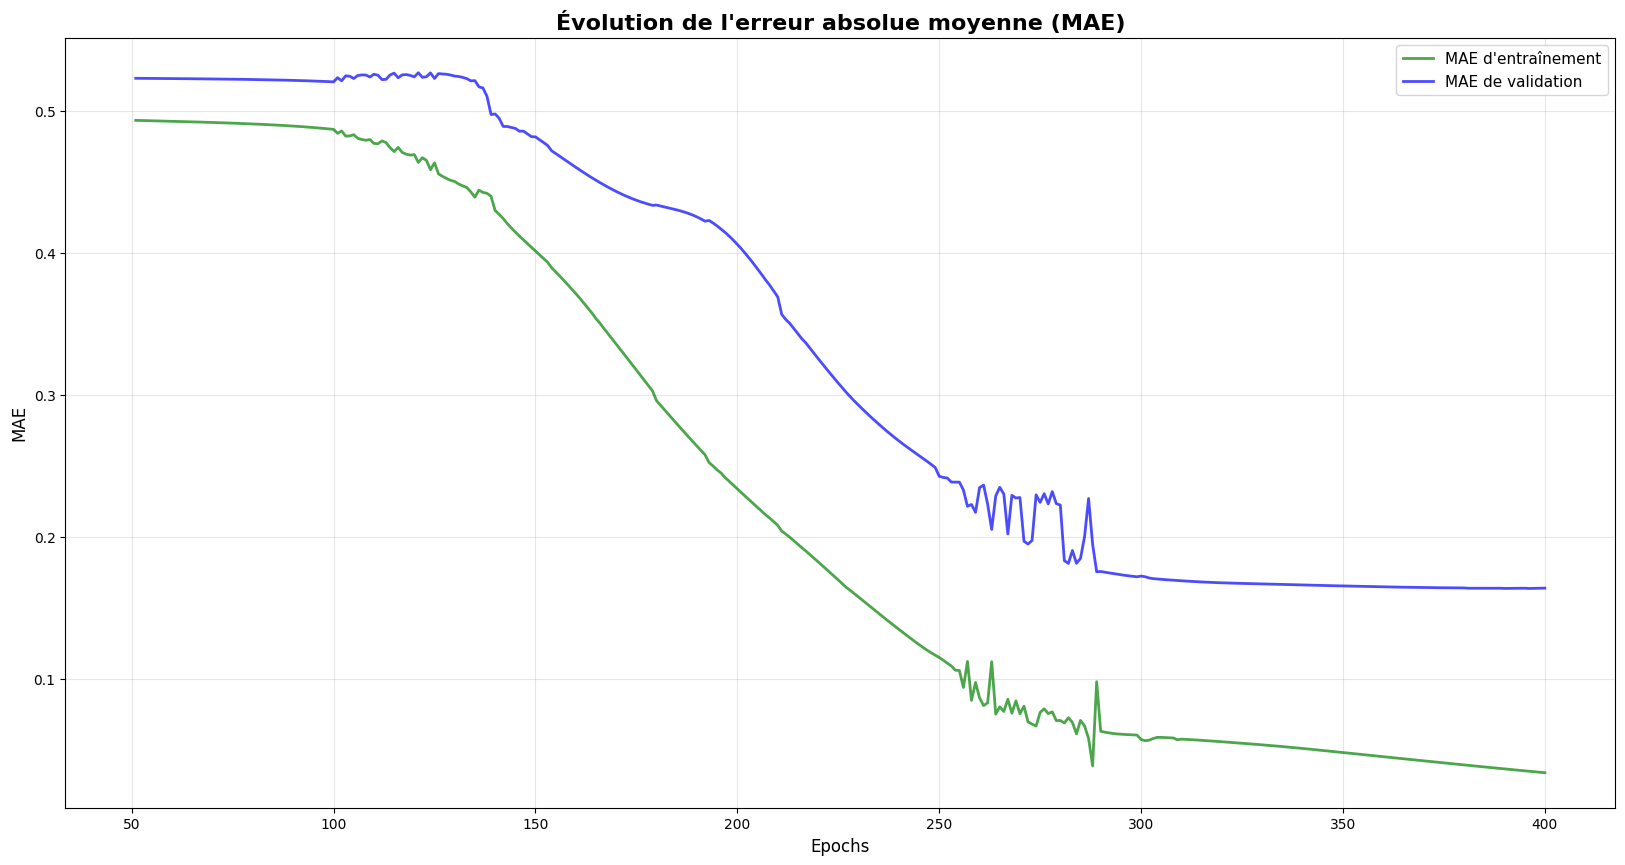

📊 MAE finale :
   - Entraînement : 0.0338
   - Validation   : 0.1639


In [ ]:
# Graphique de l'erreur absolue moyenne (MAE)
mae = history.history['mae']           # MAE sur les données d'entraînement
val_mae = history.history['val_mae']  # MAE sur les données de validation

plt.plot(epochs[SKIP:], mae[SKIP:], 'g-', label='MAE d\'entraînement', linewidth=2, alpha=0.7)
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b-', label='MAE de validation', linewidth=2, alpha=0.7)
plt.title('Évolution de l\'erreur absolue moyenne (MAE)', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"📊 MAE finale :")
print(f"   - Entraînement : {mae[-1]:.4f}")
print(f"   - Validation   : {val_mae[-1]:.4f}")


In [ ]:
# Utiliser le modèle pour prédire sur les données de test
print("🔮 Génération des prédictions sur les données de test...")
predictions = model.predict(inputs_test, verbose=1)

# Afficher les prédictions et les vraies valeurs
print("\n📊 Résultats de prédiction :")
print("=" * 60)
print("Prédictions (probabilités) :")
print(np.round(predictions, decimals=3))
print("\nVraies valeurs (labels) :")
print(outputs_test)

# Calculer la précision
correct = 0
for i in range(len(predictions)):
    pred_gesture = np.argmax(predictions[i])  # Index du geste prédit
    true_gesture = np.argmax(outputs_test[i])  # Index du vrai geste
    if pred_gesture == true_gesture:
        correct += 1

accuracy = correct / len(predictions) * 100
print(f"\n✅ Précision sur les données de test : {accuracy:.1f}% ({correct}/{len(predictions)})")
print(f"   Geste prédit = index avec la probabilité la plus élevée")

🔮 Génération des prédictions sur les données de test...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

📊 Résultats de prédiction :
Prédictions (probabilités) :
[[0.908 0.092]
 [0.983 0.017]
 [0.983 0.017]
 [0.193 0.807]
 [0.035 0.965]
 [0.983 0.017]
 [0.935 0.065]
 [0.964 0.036]
 [0.034 0.966]
 [0.493 0.507]]

Vraies valeurs (labels) :
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]

✅ Précision sur les données de test : 100.0% (10/10)
   Geste prédit = index avec la probabilité la plus élevée


In [ ]:
# ============================================
# CONVERSION EN TENSORFLOW LITE
# ============================================
# Convertir le modèle Keras en format TensorFlow Lite
# Note: Conversion sans quantification (utilise des float32)
# La quantification (int8) réduirait encore plus la taille mais nécessite plus de configuration
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Sauvegarder le modèle sur le disque
with open("gesture_model.tflite", "wb") as f:
    f.write(tflite_model)

# Afficher la taille du modèle
import os
basic_model_size = os.path.getsize("gesture_model.tflite")
print(f"✅ Modèle converti avec succès !")
print(f"📦 Taille du modèle : {basic_model_size:,} bytes ({basic_model_size/1024:.2f} KB)")

# Vérifier si la taille est acceptable pour Arduino
if basic_model_size < 100 * 1024:  # < 100 KB
    print("   ✓ Taille acceptable pour Arduino Nano 33 BLE Sense")
else:
    print("   ⚠️ Modèle assez volumineux, considérez la quantification pour réduire la taille")



Saved artifact at '/tmp/tmpwo2jrzr_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 714), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  138133789960208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138133733696592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138133733699856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138133733696784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138133733696400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138133733701968: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Modèle converti avec succès !
📦 Taille du modèle : 148,280 bytes (144.80 KB)
   ⚠️ Modèle assez volumineux, considérez la quantification pour réduire la taille


In [ ]:
# ============================================
# CONVERSION EN FICHIER HEADER C++
# ============================================
def convert_tflite_to_header(tflite_file, header_file):
    """
    Convertit un fichier TFLite en fichier header C++ compatible Arduino.

    Le modèle binaire est converti en un tableau de bytes hexadécimaux
    qui peut être inclus directement dans le code Arduino.
    """
    # Lire le fichier TFLite (mode binaire)
    with open(tflite_file, 'rb') as f:
        tflite_data = f.read()

    # Créer le fichier header C++
    with open(header_file, 'w', encoding='utf-8') as f:
        # En-tête du fichier
        f.write("// Modèle TensorFlow Lite pour Arduino\n")
        f.write("// Généré automatiquement - Ne pas modifier manuellement\n\n")

        # Déclaration du tableau de bytes
        # __attribute__((aligned(4))) : Alignement sur 4 bytes pour optimiser l'accès mémoire
        f.write("const unsigned char model[] __attribute__((aligned(4))) = {\n")

        # Convertir les bytes en format hexadécimal
        # Format: 12 bytes par ligne pour une meilleure lisibilité
        for i in range(0, len(tflite_data), 12):
            chunk = tflite_data[i:i+12]
            # Convertir chaque byte en hexadécimal (0x00 à 0xFF)
            hex_values = ', '.join(f"0x{b:02x}" for b in chunk)
            # Ajouter une virgule sauf pour le dernier chunk
            comma = "," if i + 12 < len(tflite_data) else ""
            f.write(f"  {hex_values}{comma}\n")

        f.write("};\n\n")

        # Ajouter la longueur du modèle (utile pour certaines bibliothèques)
        f.write(f"const unsigned int model_len = {len(tflite_data)};\n")

# Convertir le modèle
print("🔄 Conversion du modèle en fichier header C++...")
convert_tflite_to_header("gesture_model.tflite", "model.h")

# Afficher la taille du fichier généré
import os
model_h_size = os.path.getsize("model.h")
print(f"✅ Fichier header créé avec succès !")
print(f"📄 Taille du fichier model.h : {model_h_size:,} bytes ({model_h_size/1024:.2f} KB)")
print(f"\n📋 Prochaines étapes :")
print(f"   1. Ouvrez le fichier model.h dans votre éditeur")
print(f"   2. Ajoutez-le comme onglet dans votre sketch Arduino")
print(f"   3. Utilisez-le avec TensorFlow Lite for Microcontrollers")

🔄 Conversion du modèle en fichier header C++...
✅ Fichier header créé avec succès !
📄 Taille du fichier model.h : 914,597 bytes (893.16 KB)

📋 Prochaines étapes :
   1. Ouvrez le fichier model.h dans votre éditeur
   2. Ajoutez-le comme onglet dans votre sketch Arduino
   3. Utilisez-le avec TensorFlow Lite for Microcontrollers
